# expanding ep linking to borzoi type models

key things are it is different resolution and output size

Also, we need to make a new script, it takes in the assay type (can be combined I guess)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t")

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")

# gs_df_regulated = gs_df[gs_df["Regulated"] == True] #487
#now sort it by absolute value of EffectSize column
# gs_df_regulated = gs_df_regulated.reindex(gs_df_regulated["EffectSize"].abs().sort_values(ascending=False).index)

json_path = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
with open(json_path, 'r') as f:
    tss_dict = json.load(f)
    
name_to_ensg = tss.set_index('name')['Ensembl_ID'].to_dict()
#ensure all names are in the tss_dict
name_to_ensg = {name: ensg for name, ensg in name_to_ensg.items() if ensg in tss_dict}
        
gs_df['ensg_id'] = gs_df['measuredGeneSymbol'].map(name_to_ensg)
gs_df = gs_df.dropna(subset=['ensg_id', 'Regulated']).reset_index(drop=True)

In [2]:
#now let's see what model outputs look like

import numpy as np
import pandas as pd
import json
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
import torch
from tqdm import tqdm
import argparse
from src.dataloaders.datasets.general_dataset import GeneralDataset
from src.models.sequence.dna_embedding import DNAEmbeddingModelCaduceus
from src.tasks.decoders import EnformerDecoder
from src.tasks.encoders import JointCNN
from caduceus.configuration_caduceus import CaduceusConfig
import yaml
from omegaconf import OmegaConf
import os
import inspect
try:
    OmegaConf.register_new_resolver('eval', eval)
    OmegaConf.register_new_resolver('div_up', lambda x, y: (x + y - 1) // y)
except ValueError as e:
    if "Resolver already registered" in str(e):
            print("Resolver already exists, skipping registration.")

class Evals():
    def __init__(self,
                 ckpt_path,
                 dataset=None,
                 split = 'test',
                 device = None,
                 load_data=False,
                 **dataset_overrides #Don't pass None into overrides unless you intentionally want it to be None! Pass in items only that you need
                 ) -> None:

        #now load the cfg from the checkpoint path
        model_cfg_path = os.path.join(os.path.dirname(os.path.dirname(ckpt_path)), '.hydra', 'config.yaml')
        cfg = yaml.load(open(model_cfg_path, 'r'), Loader=yaml.FullLoader)
        cfg = OmegaConf.create(cfg)
        self.cfg = OmegaConf.to_container(cfg, resolve=True)

        state_dict = torch.load(ckpt_path, map_location='cpu')
        if device is not None:
            #if we are given a device, we will use that device
            self.device = torch.device(device)
        else:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.split = split

        #now set up dataset
        if dataset is None:
            dataset_args = self.cfg['dataset']
            assert dataset_args['mlm'] == 0 and dataset_args['acc_mlm'] == 0, "MLM and acc_mlm should be 0 for the training"
            sig = inspect.signature(GeneralDataset.__init__)
            sig = {k: v for k, v in sig.parameters.items() if k != 'self'}
            to_remove = []
            for k, v in dataset_args.items():
                if k not in sig:
                    to_remove.append(k)
            for k in to_remove:
                del dataset_args[k]
            dataset_args['split'] = split
            dataset_args['evaluating'] = True #this tells it to not do things like random shifting and rc aug, still does random masking tho, can get og sequence easily
            dataset_args['load_in'] = load_data
            dataset_args['additional_data'] = None #override so we can load the dataset!

            for k, v in dataset_overrides.items():
                if k in sig:
                    dataset_args[k] = v
                    print(f"Overriding {k} with {v}")
                else:
                    print(f"Warning: {k} not in dataset args, skipping")

            self.dataset_args = dataset_args
            self.dataset = GeneralDataset(**dataset_args)
        else:
            self.dataset = dataset

        torch.nn.modules.utils.consume_prefix_in_state_dict_if_present(
            state_dict["state_dict"], "model."
        )
        model_state_dict = state_dict["state_dict"]
        # need to remove torchmetrics. to remove keys, need to convert to list first
        for key in list(model_state_dict.keys()):
            if "torchmetrics" in key:
                model_state_dict.pop(key)
        # the state_dict keys slightly mismatch from Lightning..., so we fix it here
        decoder_state_dict = {}
        for key in list(model_state_dict.keys()):
            if "decoder" in key:
                decoder_state_dict[key[10:]] = model_state_dict.pop(key)
        encoder_state_dict = {}
        for key in list(model_state_dict.keys()):
            if "encoder" in key:
                encoder_state_dict[key[10:]] = model_state_dict.pop(key)

        cfg['model']['config'].pop('_target_')
        caduceus_cfg = CaduceusConfig(**cfg['model']['config'])

        self.backbone = DNAEmbeddingModelCaduceus(config=caduceus_cfg)
        self.backbone.load_state_dict(model_state_dict, strict=True)

        del self.cfg['decoder']['_name_']
        self.cfg['decoder']['d_model'] = self.cfg['model']['config']['d_model']
        self.decoder = EnformerDecoder(**self.cfg['decoder'])
        self.decoder.load_state_dict(decoder_state_dict, strict=True)

        del self.cfg['encoder']['_name_']
        self.cfg['encoder']['d_model'] = self.cfg['model']['config']['d_model']
        self.encoder = JointCNN(**self.cfg['encoder'])
        self.encoder.load_state_dict(encoder_state_dict, strict=True)

        self.encoder.to(self.device).eval()
        self.backbone.to(self.device).eval()
        self.decoder.to(self.device).eval()

    def __call__(self, idx=None, data=None):
        #now evaluate the model on one example
        if data is None:
            (seq,acc),_ = self.dataset[idx]

            x = seq.unsqueeze(0)
            y = acc.unsqueeze(0)
        else:
            (x,y),_ = data

            if x.dim() == 2:
                x = x.unsqueeze(0) #add batch dim
                y = y.unsqueeze(0) #add batch dim

        x,y = x.to(self.device), y.to(self.device)

        with torch.no_grad():
            x1,_ = self.encoder(x,y)
            x1,_ = self.backbone(x1)
            x1 = self.decoder(x1)

        return x1
    
ckpt_path = '/data1/lesliec/sarthak/caduceus/outputs/2026-02-25/23-21-56-969652/checkpoints/last.ckpt'
evals = Evals(ckpt_path,load_data=False, device=0)

JointMaskingEncoder: d_model=256, celltypes=None, d_input1=6, d_input2=None, joint=False, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>


In [3]:
gs_df_regulated = gs_df[gs_df["Regulated"] == True] #487
#now sort it by absolute value of EffectSize column
gs_df_regulated = gs_df_regulated.reindex(gs_df_regulated["EffectSize"].abs().sort_values(ascending=False).index)
gs_df_regulated

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id
3347,FlowFISH_K562,chr17,32909510,32913691,TMEM98|chr17:31236528-31240709:*,-0.932000,chr17,32927910.0,32927911.0,TMEM98,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|TMEM98|chr17:31236528-31240709:*,3388,32909510,32913691,ENSG00000006042
10215,FlowFISH_K562,chrX,55028229,55028268,ALAS2|chrX:55054662-55054701:*,-0.930000,chrX,55031063.0,55031064.0,ALAS2,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|ALAS2|chrX:55054662-55054701:*,10346,55028229,55028268,ENSG00000158578
5207,FlowFISH_K562,chr19,48963708,48964208,FTL|chr19:49466965-49467465:*,-0.900693,chr19,48965301.0,48965302.0,FTL,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|FTL|chr19:49466965-49467465:*,5268,48963708,48964208,ENSG00000087086
2638,FlowFISH_K562,chr12,54304241,54304761,NFE2|chr12:54698025-54698545:*,-0.892641,chr12,54301120.0,54301121.0,NFE2,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|NFE2|chr12:54698025-54698545:*,2669,54304241,54304761,ENSG00000123405
7951,FlowFISH_K562,chr6,37183271,37183514,PIM1|chr6:37151047-37151290:*,-0.888781,chr6,37170203.0,37170204.0,PIM1,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|PIM1|chr6:37151047-37151290:*,8069,37183271,37183514,ENSG00000137193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362,Gasperini2019,chr21,43397742,43398833,PKNOX1|chr21:44817622-44818713:.,-0.006984,chr21,42974510.0,42974511.0,PKNOX1,...,True,0.05,0.05,0.15,1.00,Gasperini2019|PKNOX1|chr21:44817622-44818713:.,6444,43397742,43398833,ENSG00000160199
2142,Gasperini2019,chr11,65362343,65362917,FIBP|chr11:65129814-65130388:.,-0.003123,chr11,65888538.0,65888539.0,FIBP,...,True,0.45,0.60,0.80,1.00,Gasperini2019|FIBP|chr11:65129814-65130388:.,2163,65362343,65362917,ENSG00000172500
842,Gasperini2019,chr10,12265775,12266275,SEC61A2|chr10:12307774-12308274:.,-0.001270,chr10,12129637.0,12129638.0,SEC61A2,...,True,0.00,0.00,0.00,0.10,Gasperini2019|SEC61A2|chr10:12307774-12308274:.,852,12265775,12266275,ENSG00000065665
8100,Gasperini2019,chr6,144215306,144215806,PLAGL1|chr6:144536443-144536943:.,-0.000975,chr6,144064598.0,144064599.0,PLAGL1,...,True,0.00,0.10,0.25,0.75,Gasperini2019|PLAGL1|chr6:144536443-144536943:.,8220,144215306,144215806,ENSG00000118495


In [4]:
evals.dataset.sequences

,0,1,2,3,4,5
0,chr5,41626145,41822753,test,fold3,0
1,chr11,40389266,40585874,test,fold3,1
2,chr11,32570759,32767367,test,fold3,2
3,chr6,164265822,164462430,test,fold3,3
4,chr5,13736747,13933355,test,fold3,4
...,...,...,...,...,...,...
6883,chr5,8770274,8966882,test,fold3,6883
6884,chr11,34291814,34488422,test,fold3,6884
6885,chr6,125861709,126058317,test,fold3,6885
6886,chr5,20924312,21120920,test,fold3,6886


In [5]:
#let's see what an output looks like
idx_gs = 0
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
temp_tss = tss_dict['ENSG00000006042']['tss'] #this part of converting to ENSG needs to be done!

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))
out1.shape

torch.Size([1, 6144, 2])

In [ ]:
6144*32 #predicting over these central sequence elements! but now it's clearly stranded

196608

In [9]:
np.zeros((len(gs_df), 2, 896)).nbytes/1e9

0.14737408

In [ ]:
len(gs_df)*2*896*8/1e9 #wait that's all it is lol cuz 8 bytes/float?

0.14737408

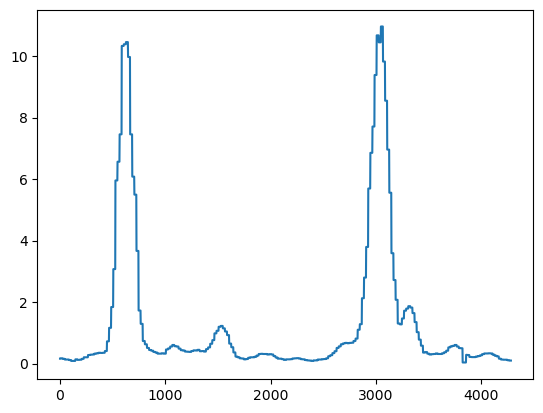

In [23]:
#let's first see acc. exact same, let's ignore this now
temp = gs_df_regulated.iloc[0]
chrom = temp['chrom']
start = temp['chromStart']
end = temp['chromEnd']
track = evals.dataset.data[chrom][0,start-50:end+50]

plt.plot(track) #isthese 2 big peaks

Text(0, 0.5, 'Predicted signal')

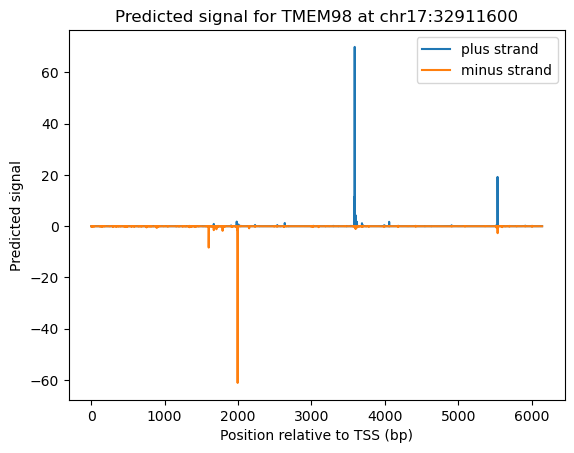

In [13]:
#anyways let's go ahead and plot this thing
import matplotlib.pyplot as plt
plt.plot(out1[0,:,0].cpu().numpy(), label='plus strand')
plt.plot(-out1[0,:,1].cpu().numpy(), label='minus strand')
plt.legend()
plt.title(f"Predicted signal for {element['measuredGeneSymbol']} at {chrom}:{mid}")
plt.xlabel("Position relative to TSS (bp)")
plt.ylabel("Predicted signal")

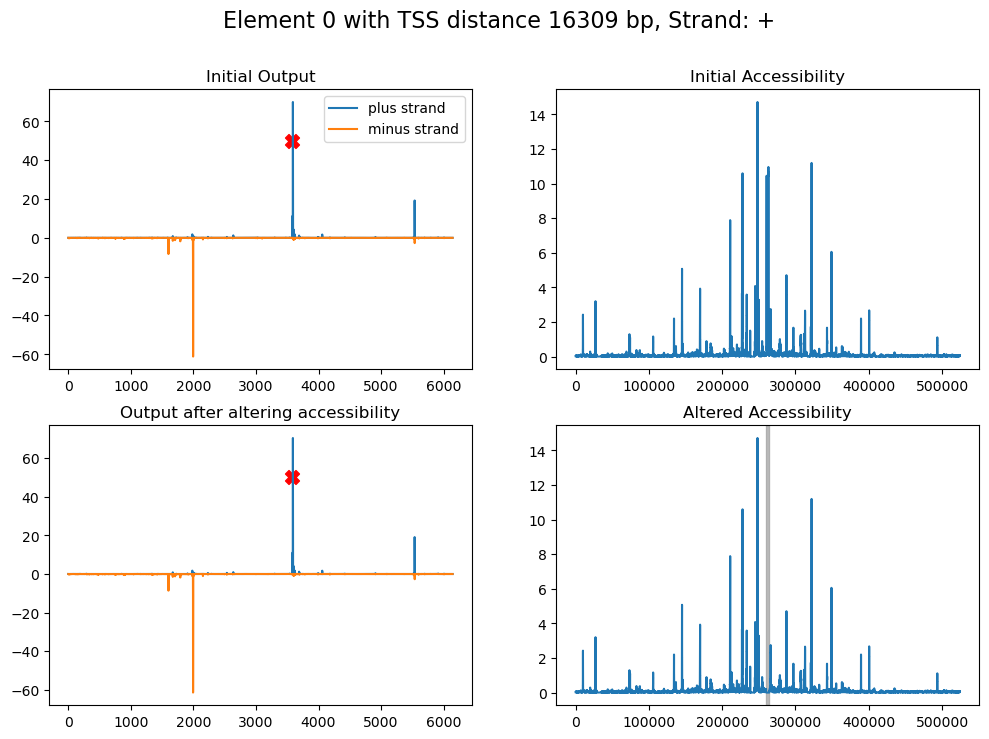

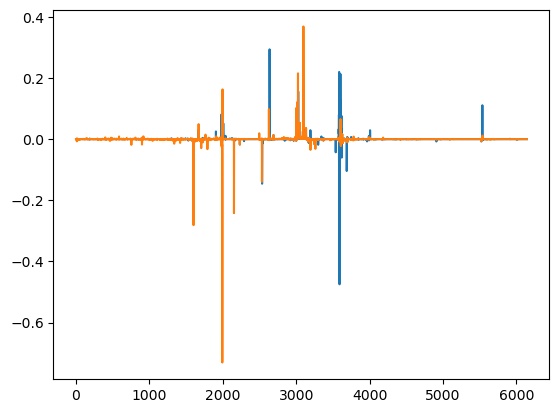

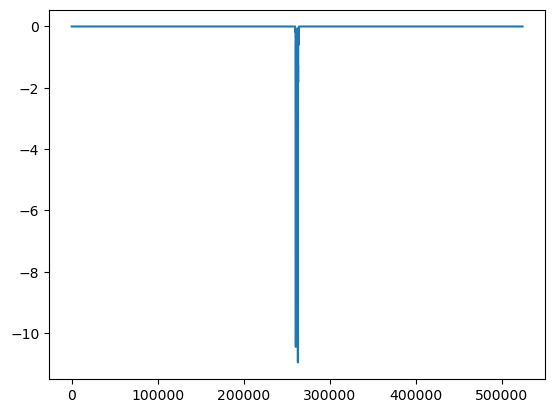

In [21]:
#now let's see idx 3

idx_gs = 0
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
ensg_id = name_to_ensg[element['measuredGeneSymbol']]
temp_tss = tss_dict[ensg_id]['tss'] #this part of converting to ENSG needs to be done!
strand = tss_dict[ensg_id]['strand']
diff = temp_tss - mid

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))

plt.suptitle(f"Element {idx_gs} with TSS distance {diff} bp, Strand: {strand}", fontsize=16)

plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1[0,:,0].cpu().numpy().squeeze(), label='plus strand')
plt.plot(-out1[0,:,1].cpu().numpy().squeeze(), label='minus strand')
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
plt.legend()
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = (element['chromEnd'] - element['chromStart'])//2 + 100
acc_copy = acc.clone()
acc_copy[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc_copy), (seq_unmask, acc_unmask)))

plt.plot(out2[0,:,0].cpu().numpy().squeeze())
plt.plot(-out2[0,:,1].cpu().numpy().squeeze())
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
# plt.plot((out1-out2).cpu().numpy().squeeze())
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc_copy[0].cpu().numpy())
#and make a gray background in the region that was altered
plt.axvspan(mid_acc-dist, mid_acc+dist, color='gray', alpha=0.5)
#clealry uses the information!! This is really good to see
plt.show()

#now plot the difference
plt.plot((out1-out2).cpu().numpy().squeeze())
plt.show()
plt.plot(acc_copy[0].cpu().numpy()-acc[0].cpu().numpy())

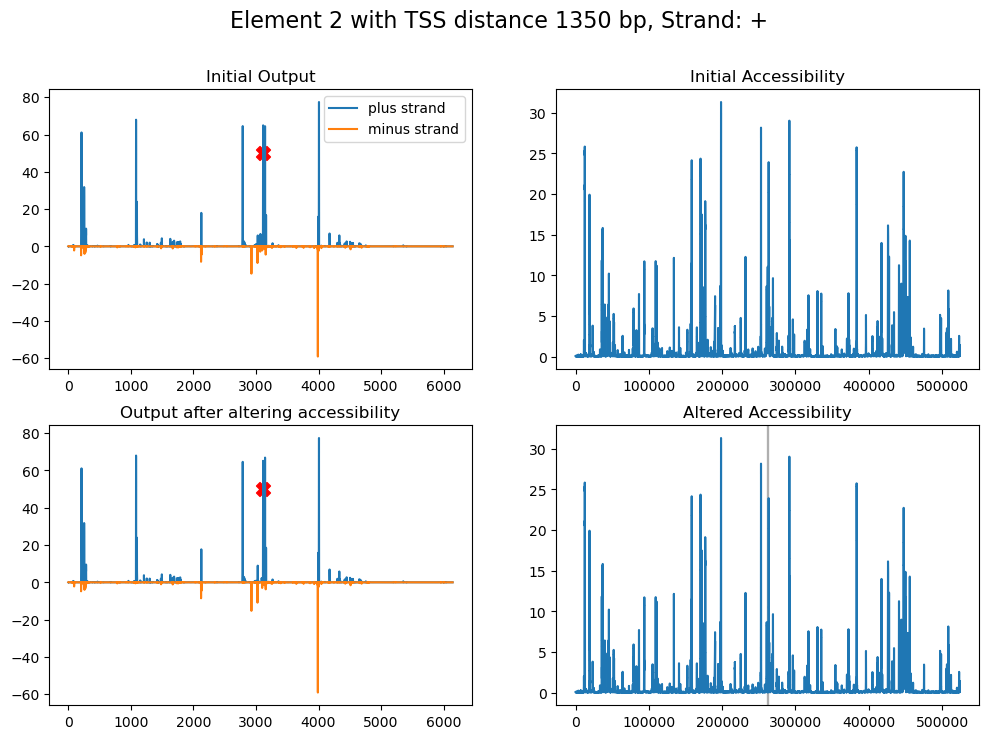

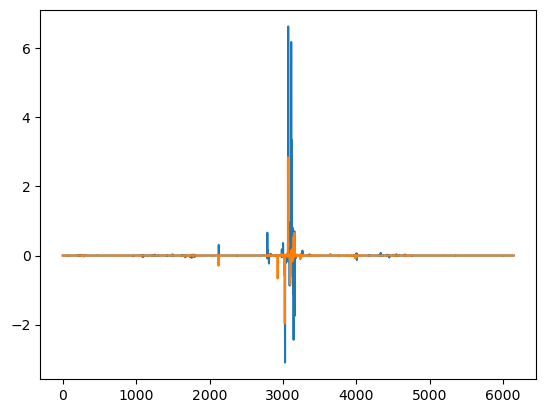

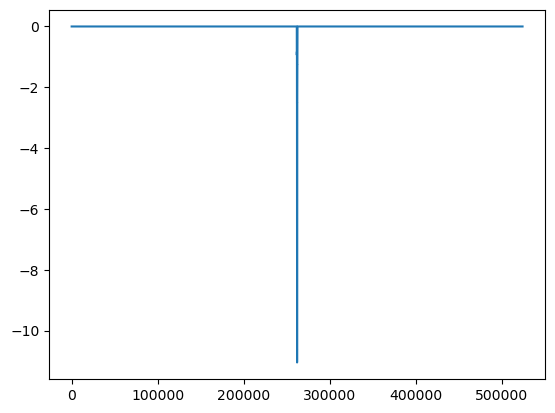

In [25]:
#now let's see idx 3

idx_gs = 2
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
ensg_id = name_to_ensg[element['measuredGeneSymbol']]
temp_tss = tss_dict[ensg_id]['tss'] #this part of converting to ENSG needs to be done!
strand = tss_dict[ensg_id]['strand']
diff = temp_tss - mid

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))

plt.suptitle(f"Element {idx_gs} with TSS distance {diff} bp, Strand: {strand}", fontsize=16)

plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1[0,:,0].cpu().numpy().squeeze(), label='plus strand')
plt.plot(-out1[0,:,1].cpu().numpy().squeeze(), label='minus strand')
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
plt.legend()
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = (element['chromEnd'] - element['chromStart'])//2 + 100
acc_copy = acc.clone()
acc_copy[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc_copy), (seq_unmask, acc_unmask)))

plt.plot(out2[0,:,0].cpu().numpy().squeeze())
plt.plot(-out2[0,:,1].cpu().numpy().squeeze())
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
# plt.plot((out1-out2).cpu().numpy().squeeze())
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc_copy[0].cpu().numpy())
#and make a gray background in the region that was altered
plt.axvspan(mid_acc-dist, mid_acc+dist, color='gray', alpha=0.5)
#clealry uses the information!! This is really good to see
plt.show()

#now plot the difference
plt.plot((out1-out2).cpu().numpy().squeeze())
plt.show()
plt.plot(acc_copy[0].cpu().numpy()-acc[0].cpu().numpy())

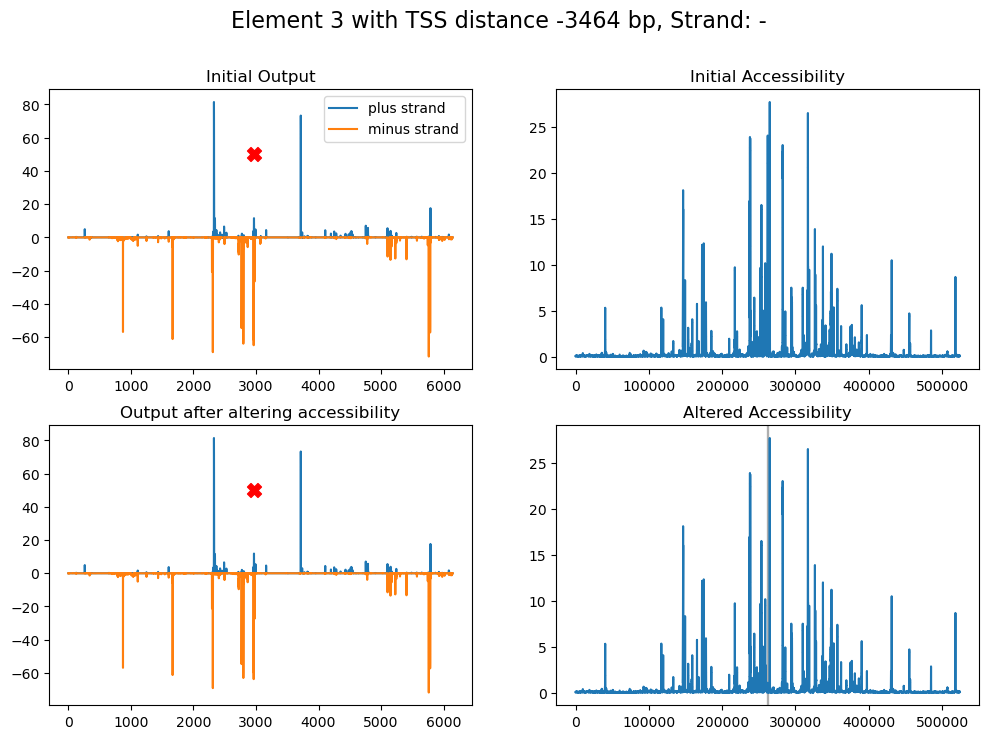

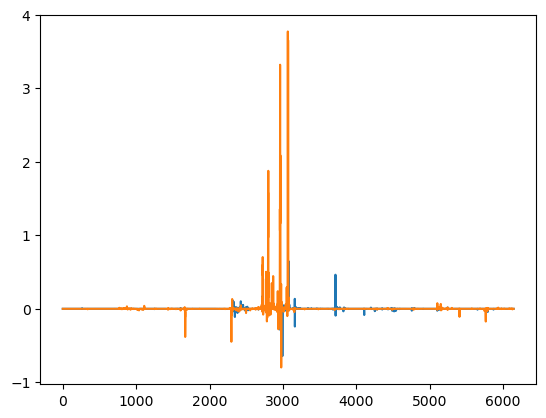

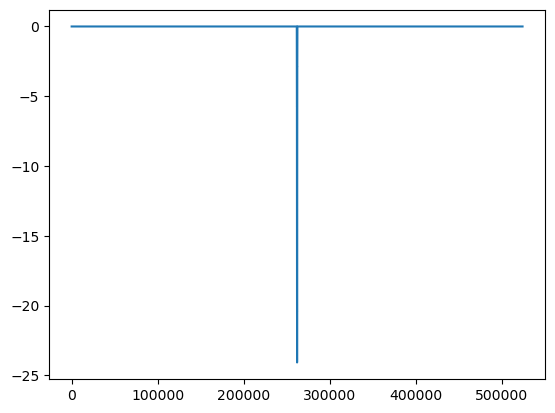

In [26]:
#now let's see idx 3

idx_gs = 3
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
ensg_id = name_to_ensg[element['measuredGeneSymbol']]
temp_tss = tss_dict[ensg_id]['tss'] #this part of converting to ENSG needs to be done!
strand = tss_dict[ensg_id]['strand']
diff = temp_tss - mid

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))

plt.suptitle(f"Element {idx_gs} with TSS distance {diff} bp, Strand: {strand}", fontsize=16)

plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1[0,:,0].cpu().numpy().squeeze(), label='plus strand')
plt.plot(-out1[0,:,1].cpu().numpy().squeeze(), label='minus strand')
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
plt.legend()
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = (element['chromEnd'] - element['chromStart'])//2 + 100
acc_copy = acc.clone()
acc_copy[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc_copy), (seq_unmask, acc_unmask)))

plt.plot(out2[0,:,0].cpu().numpy().squeeze())
plt.plot(-out2[0,:,1].cpu().numpy().squeeze())
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
# plt.plot((out1-out2).cpu().numpy().squeeze())
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc_copy[0].cpu().numpy())
#and make a gray background in the region that was altered
plt.axvspan(mid_acc-dist, mid_acc+dist, color='gray', alpha=0.5)
#clealry uses the information!! This is really good to see
plt.show()

#now plot the difference
plt.plot((out1-out2).cpu().numpy().squeeze())
plt.show()
plt.plot(acc_copy[0].cpu().numpy()-acc[0].cpu().numpy())

In [ ]:
#seems fine, just have to account for strand, clearly seeing changes in strand
#but potentially undertrained compared to the CAGE model

#so just account for strand, different output and bin size. And that it has multiple modalities
#unclear what to use if we use both? clearly check both!

# let's check RNA

In [27]:
ckpt_path = '/data1/lesliec/sarthak/caduceus/outputs/2026-02-25/23-33-18-468516/checkpoints/last.ckpt'
evals = Evals(ckpt_path,load_data=False, device=0)

JointMaskingEncoder: d_model=256, celltypes=None, d_input1=6, d_input2=None, joint=False, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>


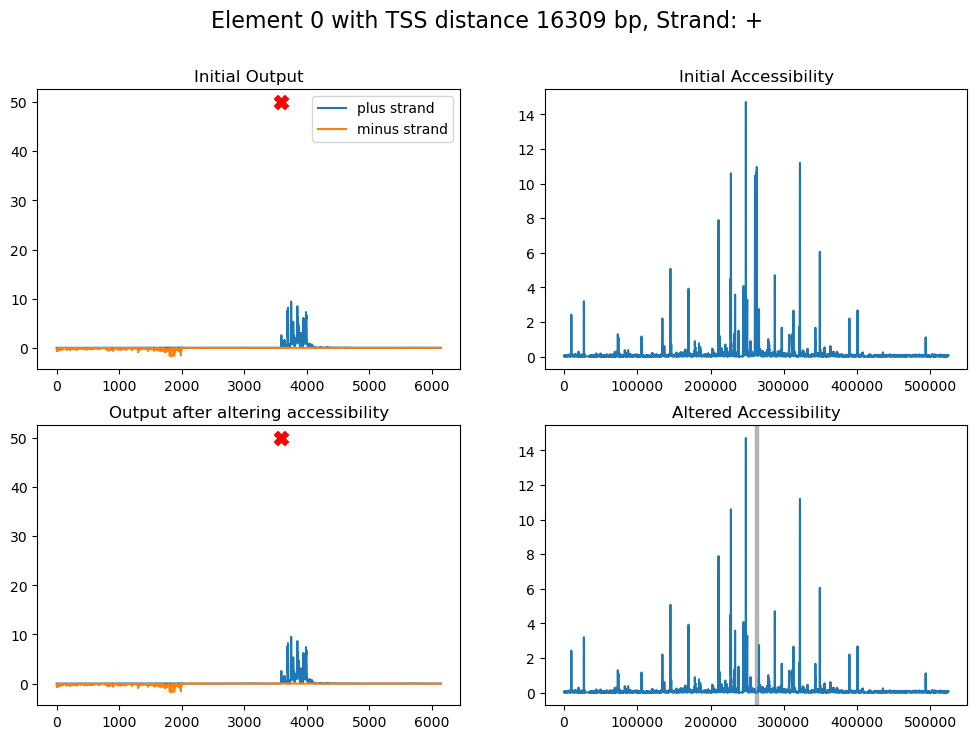

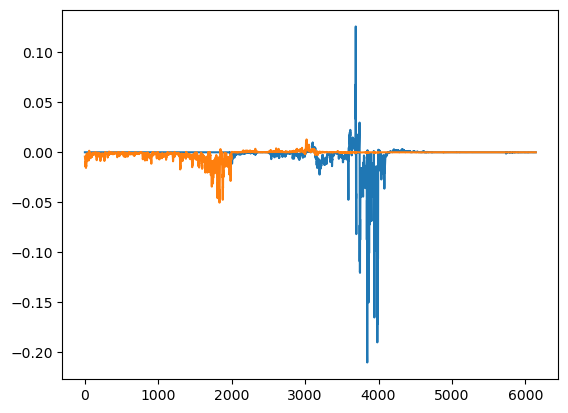

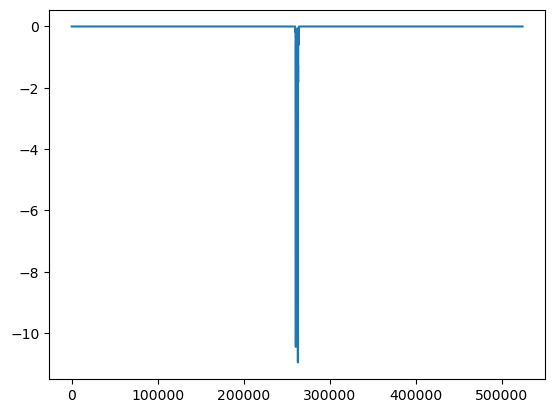

In [ ]:
idx_gs = 0
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
ensg_id = name_to_ensg[element['measuredGeneSymbol']]
temp_tss = tss_dict[ensg_id]['tss'] #this part of converting to ENSG needs to be done!
strand = tss_dict[ensg_id]['strand']
diff = temp_tss - mid

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))

plt.suptitle(f"Element {idx_gs} with TSS distance {diff} bp, Strand: {strand}", fontsize=16)

plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1[0,:,0].cpu().numpy().squeeze(), label='plus strand')
plt.plot(-out1[0,:,1].cpu().numpy().squeeze(), label='minus strand')
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
plt.legend()
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = (element['chromEnd'] - element['chromStart'])//2 + 100
acc_copy = acc.clone()
acc_copy[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc_copy), (seq_unmask, acc_unmask)))

plt.plot(out2[0,:,0].cpu().numpy().squeeze())
plt.plot(-out2[0,:,1].cpu().numpy().squeeze())
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
# plt.plot((out1-out2).cpu().numpy().squeeze())
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc_copy[0].cpu().numpy())
#and make a gray background in the region that was altered
plt.axvspan(mid_acc-dist, mid_acc+dist, color='gray', alpha=0.5)
#clealry uses the information!! This is really good to see
plt.show()

#now plot the difference
plt.plot((out1-out2).cpu().numpy().squeeze())
plt.show()
plt.plot(acc_copy[0].cpu().numpy()-acc[0].cpu().numpy())

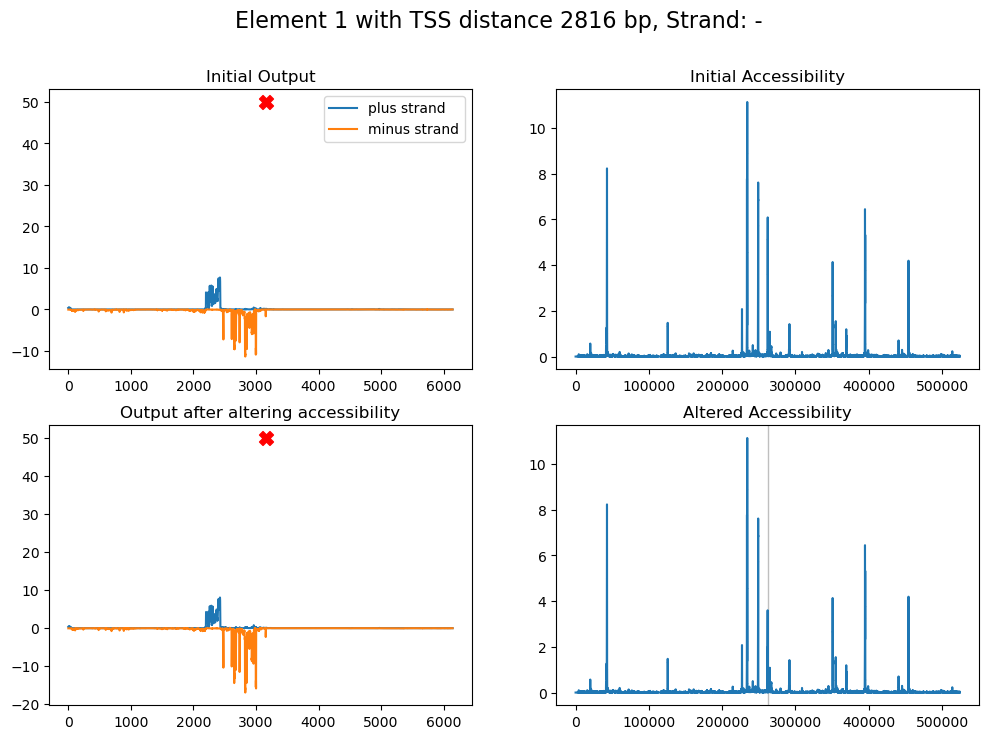

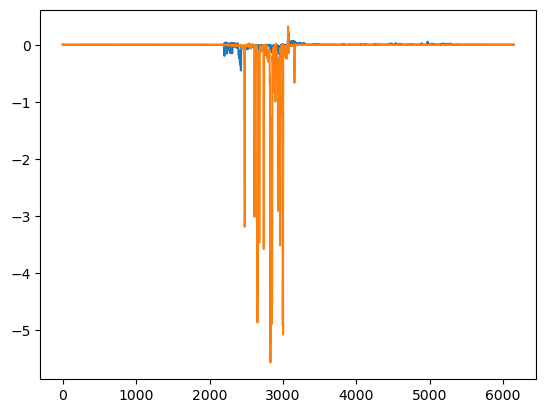

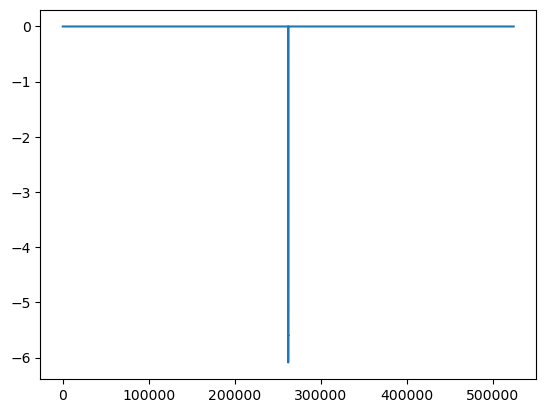

In [29]:
idx_gs = 1
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
ensg_id = name_to_ensg[element['measuredGeneSymbol']]
temp_tss = tss_dict[ensg_id]['tss'] #this part of converting to ENSG needs to be done!
strand = tss_dict[ensg_id]['strand']
diff = temp_tss - mid

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))

plt.suptitle(f"Element {idx_gs} with TSS distance {diff} bp, Strand: {strand}", fontsize=16)

plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1[0,:,0].cpu().numpy().squeeze(), label='plus strand')
plt.plot(-out1[0,:,1].cpu().numpy().squeeze(), label='minus strand')
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
plt.legend()
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = (element['chromEnd'] - element['chromStart'])//2 + 100
acc_copy = acc.clone()
acc_copy[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc_copy), (seq_unmask, acc_unmask)))

plt.plot(out2[0,:,0].cpu().numpy().squeeze())
plt.plot(-out2[0,:,1].cpu().numpy().squeeze())
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
# plt.plot((out1-out2).cpu().numpy().squeeze())
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc_copy[0].cpu().numpy())
#and make a gray background in the region that was altered
plt.axvspan(mid_acc-dist, mid_acc+dist, color='gray', alpha=0.5)
#clealry uses the information!! This is really good to see
plt.show()

#now plot the difference
plt.plot((out1-out2).cpu().numpy().squeeze())
plt.show()
plt.plot(acc_copy[0].cpu().numpy()-acc[0].cpu().numpy())

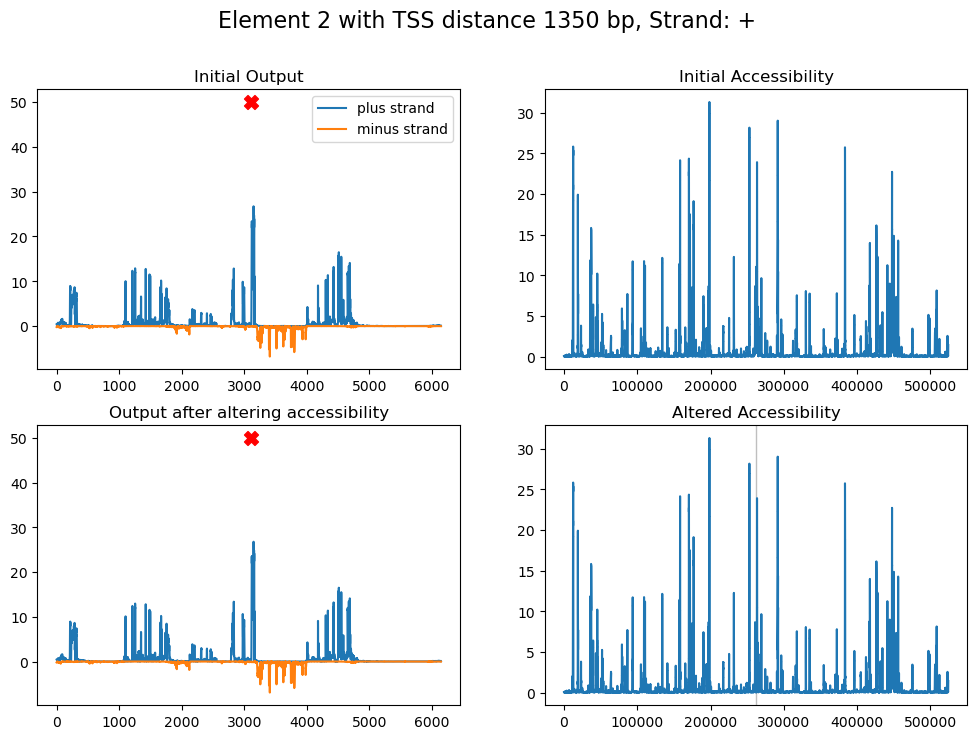

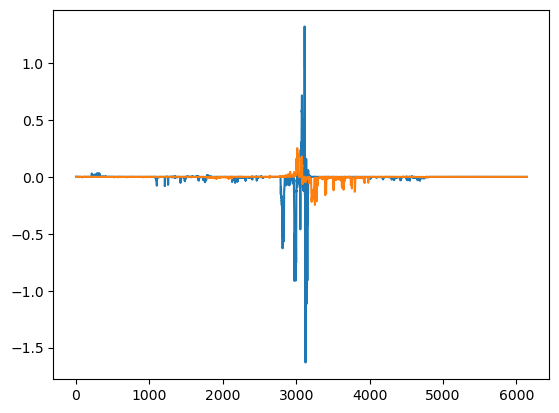

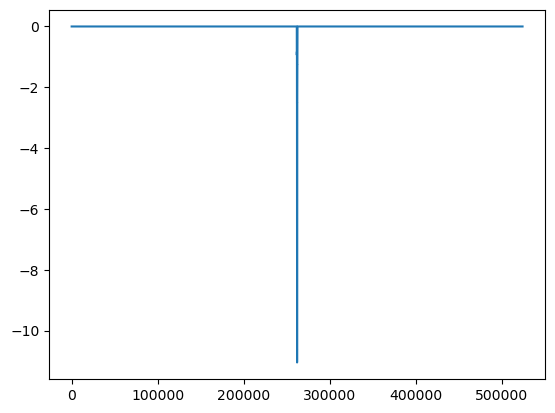

In [30]:
idx_gs = 2
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
ensg_id = name_to_ensg[element['measuredGeneSymbol']]
temp_tss = tss_dict[ensg_id]['tss'] #this part of converting to ENSG needs to be done!
strand = tss_dict[ensg_id]['strand']
diff = temp_tss - mid

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))

plt.suptitle(f"Element {idx_gs} with TSS distance {diff} bp, Strand: {strand}", fontsize=16)

plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1[0,:,0].cpu().numpy().squeeze(), label='plus strand')
plt.plot(-out1[0,:,1].cpu().numpy().squeeze(), label='minus strand')
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
plt.legend()
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = (element['chromEnd'] - element['chromStart'])//2 + 100
acc_copy = acc.clone()
acc_copy[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc_copy), (seq_unmask, acc_unmask)))

plt.plot(out2[0,:,0].cpu().numpy().squeeze())
plt.plot(-out2[0,:,1].cpu().numpy().squeeze())
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
# plt.plot((out1-out2).cpu().numpy().squeeze())
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc_copy[0].cpu().numpy())
#and make a gray background in the region that was altered
plt.axvspan(mid_acc-dist, mid_acc+dist, color='gray', alpha=0.5)
#clealry uses the information!! This is really good to see
plt.show()

#now plot the difference
plt.plot((out1-out2).cpu().numpy().squeeze())
plt.show()
plt.plot(acc_copy[0].cpu().numpy()-acc[0].cpu().numpy())

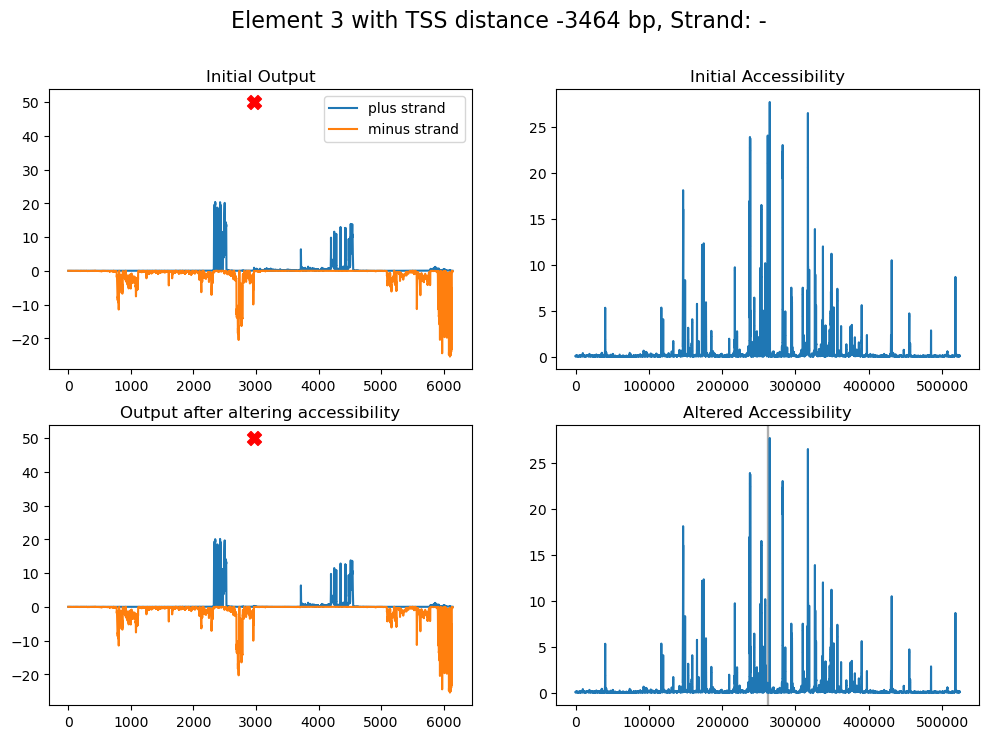

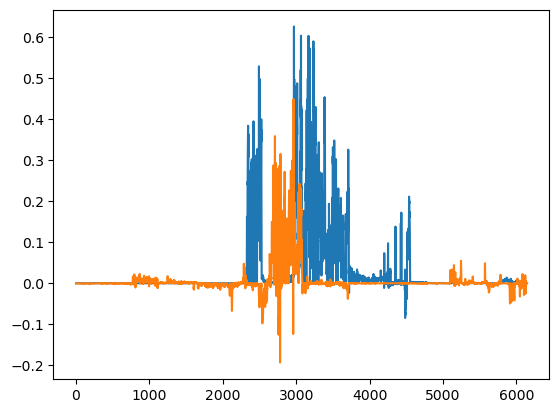

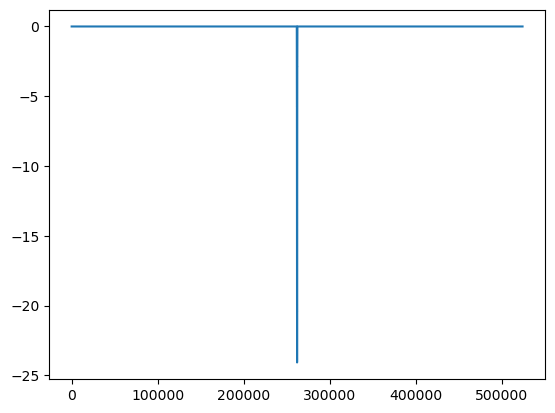

In [31]:
idx_gs = 3
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
ensg_id = name_to_ensg[element['measuredGeneSymbol']]
temp_tss = tss_dict[ensg_id]['tss'] #this part of converting to ENSG needs to be done!
strand = tss_dict[ensg_id]['strand']
diff = temp_tss - mid

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))

plt.suptitle(f"Element {idx_gs} with TSS distance {diff} bp, Strand: {strand}", fontsize=16)

plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1[0,:,0].cpu().numpy().squeeze(), label='plus strand')
plt.plot(-out1[0,:,1].cpu().numpy().squeeze(), label='minus strand')
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
plt.legend()
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = (element['chromEnd'] - element['chromStart'])//2 + 100
acc_copy = acc.clone()
acc_copy[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc_copy), (seq_unmask, acc_unmask)))

plt.plot(out2[0,:,0].cpu().numpy().squeeze())
plt.plot(-out2[0,:,1].cpu().numpy().squeeze())
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
# plt.plot((out1-out2).cpu().numpy().squeeze())
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc_copy[0].cpu().numpy())
#and make a gray background in the region that was altered
plt.axvspan(mid_acc-dist, mid_acc+dist, color='gray', alpha=0.5)
#clealry uses the information!! This is really good to see
plt.show()

#now plot the difference
plt.plot((out1-out2).cpu().numpy().squeeze())
plt.show()
plt.plot(acc_copy[0].cpu().numpy()-acc[0].cpu().numpy())

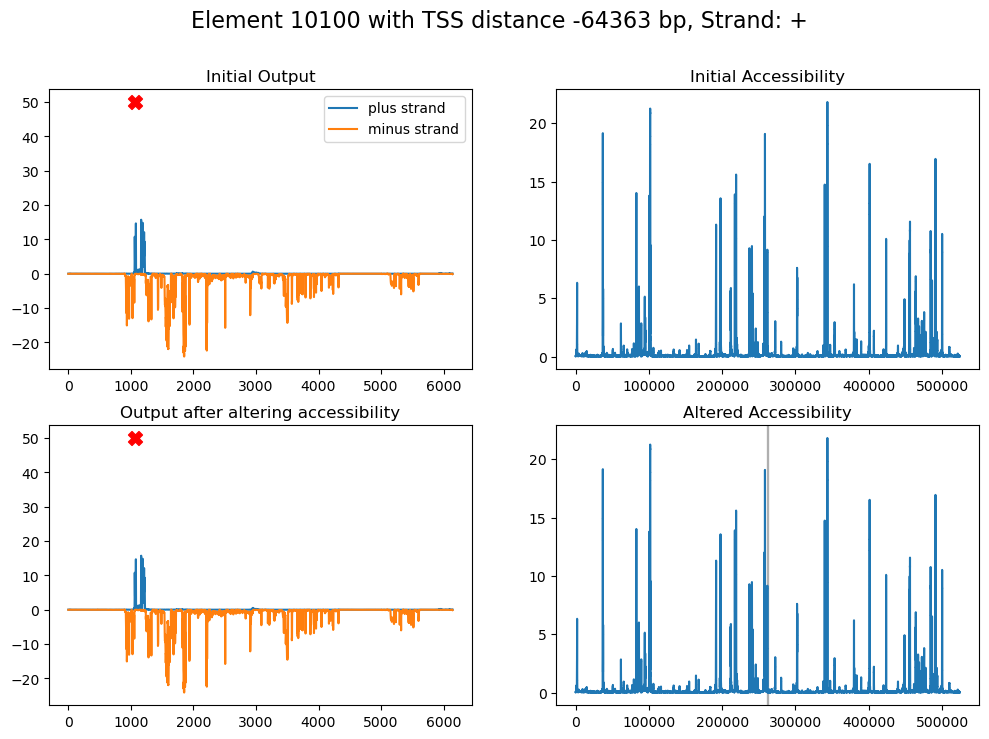

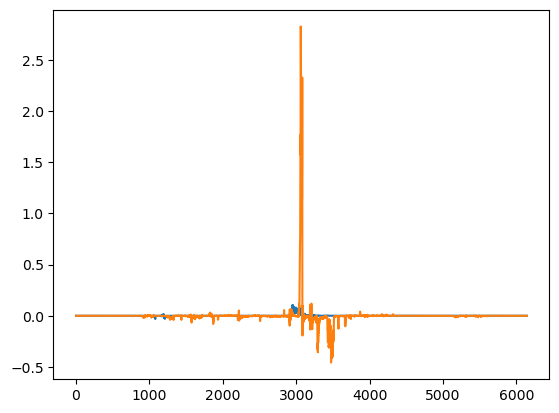

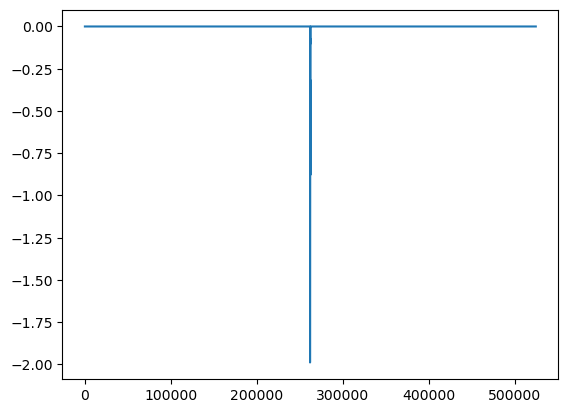

In [40]:
idx_gs = 10100
element = gs_df.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
ensg_id = name_to_ensg[element['measuredGeneSymbol']]
temp_tss = tss_dict[ensg_id]['tss'] #this part of converting to ENSG needs to be done!
strand = tss_dict[ensg_id]['strand']
diff = temp_tss - mid
if diff > 196608//2 or diff < -196608//2:
    raise ValueError(f"TSS is too far from the element for it to be in the input sequence, diff is {diff} bp")
    

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))

plt.suptitle(f"Element {idx_gs} with TSS distance {diff} bp, Strand: {strand}", fontsize=16)

plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1[0,:,0].cpu().numpy().squeeze(), label='plus strand')
plt.plot(-out1[0,:,1].cpu().numpy().squeeze(), label='minus strand')
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
plt.legend()
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = (element['chromEnd'] - element['chromStart'])//2 + 100
acc_copy = acc.clone()
acc_copy[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc_copy), (seq_unmask, acc_unmask)))

plt.plot(out2[0,:,0].cpu().numpy().squeeze())
plt.plot(-out2[0,:,1].cpu().numpy().squeeze())
plt.scatter(6144//2 + diff//32, 50, color='r', marker='X', s=100)
# plt.plot((out1-out2).cpu().numpy().squeeze())
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc_copy[0].cpu().numpy())
#and make a gray background in the region that was altered
plt.axvspan(mid_acc-dist, mid_acc+dist, color='gray', alpha=0.5)
#clealry uses the information!! This is really good to see
plt.show()

#now plot the difference
plt.plot((out1-out2).cpu().numpy().squeeze())
plt.show()
plt.plot(acc_copy[0].cpu().numpy()-acc[0].cpu().numpy())

In [41]:
element

dataset                                               FlowFISH_K562
chrom                                                          chrX
chromStart                                                 48962024
chromEnd                                                   48962524
name                                 PQBP1|chrX:48819285-48819785:*
EffectSize                                                -0.026291
chrTSS                                                         chrX
startTSS                                                 48897912.0
endTSS                                                   48897913.0
measuredGeneSymbol                                            PQBP1
Significant                                                   False
pValueAdjusted                                             0.854383
PowerAtEffectSize25                                             1.0
ValidConnection                                                True
CellType                                        

# now let's run across all

Output array layout (float32, (n_elements, n_rows, 6144)):

assay_type	n_rows	Row indices
CAGE or RNA	4	[0]=before+, [1]=before-, [2]=after+, [3]=after-
both	8	[0-3]=before (CAGE+, CAGE-, RNA+, RNA-), [4-7]=after (same)

**Output array layout** (`float32`, `(n_elements, n_rows, 6144)`):
| `assay_type` | `n_rows` | Row indices |
|---|---|---|
| `CAGE` or `RNA` | 4 | `[0]=before+, [1]=before-, [2]=after+, [3]=after-` |
| `both` | 8 | `[0-3]=before (CAGE+, CAGE-, RNA+, RNA-)`, `[4-7]=after (same)` |
